# Frequency and Keyness

## Housekeeping (no interaction required)

In [1]:
%pip install simplemma
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 MB 8.9 MB/s eta 0:00:00


In [93]:
import os
import random
import time
from pathlib import Path

import pandas as pd
import nltk
import simplemma
from tqdm.notebook import tqdm

tqdm.pandas()
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')
ZB_MODULE = '03' # Identifier of the ZB Summer School module, used for naming output files

## Setup (Interaction required)

In [4]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armensteuer_and_similars"
### ⬆️⬆️⬆️

💽 You only need to run the cell below if you want to work with your own query.

*Once prompted, give all demanded permissions*

In [5]:
# 💽
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


## Load the data


### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [7]:
LOAD_OWN_DATA = False
if LOAD_OWN_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.02.parquet" # Use data from filtering module
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load from Github

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [8]:
RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.01.parquet" # CHANGE TO 02
raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

⚙️ Only for development, delete for summer school!

In [9]:
raw_df = raw_df.reset_index()[["id", "meta.date", "meta.mediaTitle", "text.itemTypeLabel", "text.content", "text.contentLength"]]
raw_df = raw_df.set_index("id")

### Parse data

In [10]:
raw_df["year"] = pd.to_datetime(raw_df["meta.date"]).dt.year

## Preprocess Corpus

In [128]:
def sentencize(s: str) -> list[str]:
    sentences = nltk.tokenize.sent_tokenize(s, language="german")
    return sentences

def tokenize(s: str) -> list[str]:
    tokens = nltk.tokenize.word_tokenize(s, language="german")
    return tokens

def lemmatize(s: list[str]) -> list[str]:
    lemmatized = [simplemma.lemmatize(word, lang="de") for word in s]
    return lemmatized

import re
replacement_pairs = [
    (re.compile(r"^Th"), "T"),
    (re.compile(r"^th"), "t"),
    (re.compile(r"th$"), "t"),
    (re.compile(r"ß"), "s"),
]
def normalize(s: list[str]) -> list[str]:
    tokens = []
    for tok in s:
        for regex, replacement in replacement_pairs:
            tok = regex.sub(replacement, tok)
        tokens.append(tok)
    return tokens

tqdm.pandas(desc="Applying sentencization")
raw_df["_sentences"] = raw_df["text.content"].progress_apply(sentencize)

tqdm.pandas(desc="Applying tokenization")
raw_df["tokens"] = raw_df["_sentences"].progress_apply(lambda sentences: [tokenize(sentence) for sentence in sentences])

#tqdm.pandas(desc="Applying lemmatization")
#raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(normalize(token_list)) for token_list in tokens])

tqdm.pandas(desc="Applying lemmatization")
raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [normalize(token_list) for token_list in tokens])


Applying sentencization:   0%|          | 0/4044 [00:00<?, ?it/s]

Applying tokenization:   0%|          | 0/4044 [00:00<?, ?it/s]

Applying lemmatization:   0%|          | 0/4044 [00:00<?, ?it/s]

In [14]:
raw_df.drop(columns=["_sentences", "text.content", "year", "tokens"]).to_parquet(DATA_DIR / f"{CORPUS_NAME}.lemmas.03.parquet")
raw_df.drop(columns=["_sentences", "text.content", "year", "tokens"]).to_json(DATA_DIR / f"{CORPUS_NAME}.lemmas.03.jsonl", orient="records", lines=True)

raw_df.drop(columns=["_sentences", "text.content", "year", "lemmas"]).to_parquet(DATA_DIR / f"{CORPUS_NAME}.wordforms.03.parquet")
raw_df.drop(columns=["_sentences", "text.content", "year", "lemmas"]).to_json(DATA_DIR / f"{CORPUS_NAME}.wordforms.03.jsonl", orient="records", lines=True)


## Frequency Analyses

In [22]:
from collections import Counter

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

lemma_c = count_tokens(raw_df, "lemmas")

lemma_c.most_common(10)

Counting Tokens:   0%|          | 0/4044 [00:00<?, ?it/s]

[('der', 1006631),
 (',', 793809),
 ('.', 717320),
 ('»', 575762),
 ('«', 526400),
 ('und', 203142),
 ('ein', 176642),
 ('in', 172671),
 ('sein', 166322),
 (';', 140861)]

### Compare Frequency across Time

In [85]:
from typing import Dict
import matplotlib.pyplot as plt

class FrequencyAnalysisDiachronic:
    def __init__(self, df: pd.DataFrame, column: str, n_years: int):
        self.df = df.copy()
        self.column = column

        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()

        self.interval_counters = self.get_frequency_by_interval(n_years)
        self.intervals = list(self.interval_counters.keys())
        self.interval_total = {
            interval: sum(counter.values())
            for interval, counter
            in self.interval_counters.items()
        }

    def get_frequency_by_interval(self, n_years: int) -> Dict[str, Counter]:
        if n_years <= 0:
            raise ValueError("n_years must be a positive integer.")

        # Snap start to the nearest lower multiple of n_years
        start = (self.min_year // n_years) * n_years
        stop = self.max_year + n_years

        bins = list(range(start, stop, n_years))
        labels = [f"{y}–{y + n_years - 1}" for y in bins[:-1]]

        # Assign each document to a year bucket
        # With n_years = 25:
        #   1833 -> 1825 -> "1825-1849"
        #   1900 -> 1900 -> "1900-1924"
        #   1898 -> 1875 -> "1875-1899"
        self.df["year_interval"] = pd.cut(self.df["year"], bins=bins, labels=labels, right=False)

        # Calculate counts for each interval
        interval_counters = {}
        # Filter out NaN intervals if any document year falls outside the defined bins
        for interval in tqdm(labels, desc="Iterating intervals"):
            group_df = self.df[self.df["year_interval"] == interval]
            interval_counters[interval] = count_tokens(group_df, column=self.column)
        return interval_counters

    def get_abs_frequencies_for_word(self, word: str) -> Dict[str, int]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word]
        return frequencies

    def get_rel_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word] / self.interval_total[interval]
        return frequencies

    def get_norm_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = self.get_rel_frequencies_for_word(word)
        frequencies = {interval: freq * 1000000 for interval, freq in frequencies.items()}
        return frequencies

    def plot_interval_totals(self):
        fig, ax = plt.subplots(figsize=(12, 3))

        ax.bar(self.intervals, [self.interval_total[interval] for interval in self.intervals])

        ax.tick_params(axis='x', rotation=45)
        # ax.legend(title="Words")
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()

    def plot_relative_frequencies(self, words: list[str]):
        fig, ax = plt.subplots(figsize=(12, 6))

        for word in words:
            rel_freqs = self.get_rel_frequencies_for_word(word)
            series = pd.Series(rel_freqs)
            ax.plot(series.index.astype(str), series.values, label=word, marker='o', markersize=4)

        ax.tick_params(axis='x', rotation=45)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()
        ax.plot()


In [56]:
fa_diachron = FrequencyAnalysisDiachronic(raw_df, "lemmas", 10)

Iterating intervals:   0%|          | 0/20 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/2 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/11 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/10 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/27 [00:00<?, ?it/s]

...

Counting Tokens:   0%|          | 0/609 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/289 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/95 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/38 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/2 [00:00<?, ?it/s]

In [86]:
fa_diachron.__class__ = FrequencyAnalysisDiachronic

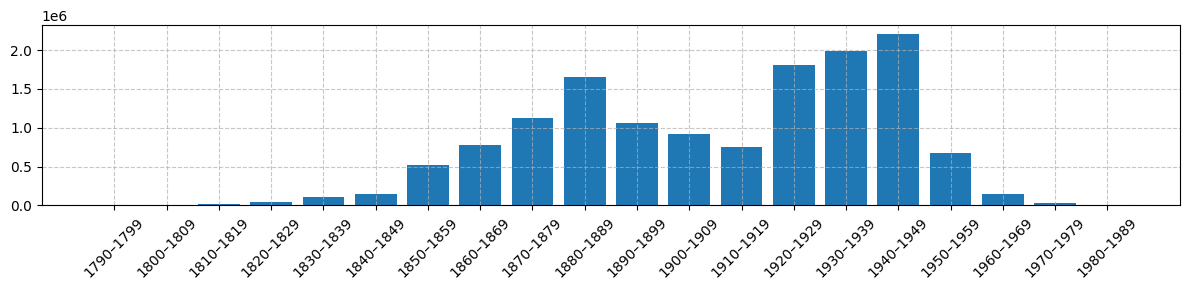

In [87]:
fa_diachron.plot_interval_totals()

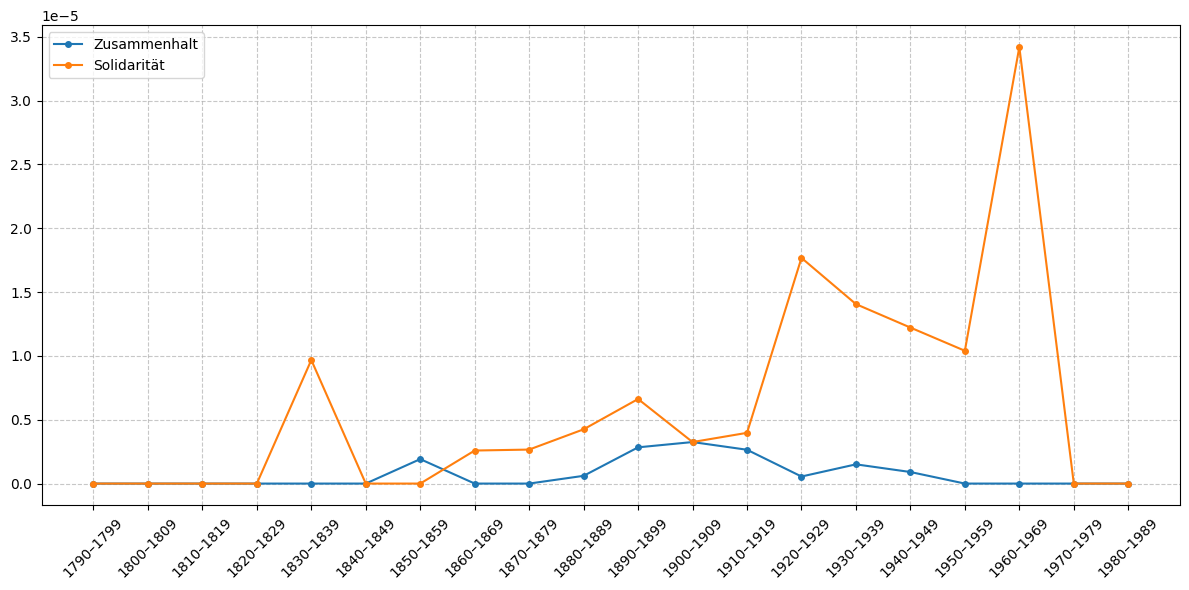

In [88]:
fa_diachron.plot_relative_frequencies(["Bundesrath", "Bundesrat"])

## Compare Frequencies

In [123]:
import math

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

class KeynessComparer:
    def __init__(self, df1: pd.DataFrame, df2: pd.DataFrame, column: str = "lemmas", freq_filter=5):
        self.df1 = df1
        self.df2 = df2
        self.column = column
        self.freq_filter = freq_filter

        self.counter1 = count_tokens(self.df1, self.column)
        self.counter2 = count_tokens(self.df2, self.column)

        self.total_tokens1 = sum(self.counter1.values())
        self.total_tokens2 = sum(self.counter2.values())

        # Apply the frequency filter
        self.counter1 = Counter({token: count for token, count in self.counter1.items() if count >= self.freq_filter})
        self.counter2 = Counter({token: count for token, count in self.counter2.items() if count >= self.freq_filter})

        self.df = self.build_contingency_df()

    def build_contingency_df(self) -> pd.DataFrame:
        all_tokens = set(self.counter1.keys()) | set(self.counter2.keys())
        data = []
        for token in tqdm(all_tokens, desc="Build Contingency Table"):
            observed_tok_1 = self.counter1[token]
            observed_tok_2 = self.counter2[token]
            observed_notok_1 = self.total_tokens1 - observed_tok_1
            observed_notok_2 = self.total_tokens2 - observed_tok_2

            # Expected frequencies under the null hypothesis of no association between token and corpus
            expected_tok_1 = (observed_tok_1 + observed_tok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_tok_2 = (observed_tok_1 + observed_tok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_1 = (observed_notok_1 + observed_notok_2) * self.total_tokens1 / (self.total_tokens1 + self.total_tokens2)
            expected_notok_2 = (observed_notok_1 + observed_notok_2) * self.total_tokens2 / (self.total_tokens1 + self.total_tokens2)

            data.append({
                "token": token,
                "observed_tok_1": observed_tok_1,
                "observed_tok_2": observed_tok_2,
                "observed_notok_1": observed_notok_1,
                "observed_notok_2": observed_notok_2,
                "expected_tok_1": expected_tok_1,
                "expected_tok_2": expected_tok_2,
                "expected_notok_1": expected_notok_1,
                "expected_notok_2": expected_notok_2,
                "prevalent_1": True if observed_tok_1 > expected_tok_1 else False,
            })
        contingency_df = pd.DataFrame(data)
        return contingency_df

    def log_likelihood_ratio(self, contingency_row: pd.Series) -> float:
        G = 0.0
        for token_presence in ["tok", "notok"]:
            for corpus in ["1", "2"]:
                observed = contingency_row[f"observed_{token_presence}_{corpus}"]
                expected = contingency_row[f"expected_{token_presence}_{corpus}"]

                if observed > 0 and expected > 0:
                    G += observed * math.log(observed / expected)
        return 2 * G


    def log_ratio(self, contingency_row: pd.Series) -> float:
        observed_tok_1 = contingency_row["observed_tok_1"]
        observed_tok_2 = contingency_row["observed_tok_2"]
        logprob1 = math.log((observed_tok_1 + 1/2) / (self.total_tokens1 + 1/2))  # Add-one smoothing
        logprob2 = math.log((observed_tok_2 + 1/2) / (self.total_tokens2 + 1/2))  # Add-one smoothing

        return logprob1 - logprob2

    def build_keyness_df(self) -> pd.DataFrame:
        tqdm.pandas(desc="Calculating log likelihood ratio")
        self.df["llr"] = self.df.progress_apply(self.log_likelihood_ratio, axis=1)
        tqdm.pandas(desc="Calculating log ratio")
        self.df["log_ratio"] = self.df.progress_apply(self.log_ratio, axis=1)
        return self.df

In [124]:
df_pre1920 = raw_df[raw_df["year"] < 1920]
df_post1920 = raw_df[raw_df["year"] >= 1920]

kf = KeynessComparer(df_pre1920, df_post1920)

Counting Tokens:   0%|          | 0/2123 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/1921 [00:00<?, ?it/s]

Build Contingency Table:   0%|          | 0/64354 [00:00<?, ?it/s]

In [125]:
kf.__class__ = KeynessComparer

In [126]:
kf.build_keyness_df()

Calculating log likelihood ratio:   0%|          | 0/64354 [00:00<?, ?it/s]

Calculating log ratio:   0%|          | 0/64354 [00:00<?, ?it/s]

,token,observed_tok_1,observed_tok_2,observed_notok_1,observed_notok_2,expected_tok_1,expected_tok_2,expected_notok_1,expected_notok_2,prevalent_1,llr,log_ratio
0,Heilkunde,7,5,7118352,6860958,6.110476,5.889524,7.118353e+06,6.860957e+06,True,0.265304,0.273326
1,Diethelm,18,14,7118341,6860949,16.294602,15.705398,7.118343e+06,6.860947e+06,True,0.364844,0.206793
2,zweischneidig,5,0,7118354,6860963,2.546032,2.453968,7.118356e+06,6.860961e+06,True,6.749022,2.361066
3,umschreiben,12,101,7118347,6860862,57.540313,55.459687,7.118301e+06,6.860908e+06,False,83.470447,-2.131160
4,Suppenhuhn,13,0,7118346,6860963,6.619682,6.380318,7.118352e+06,6.860957e+06,True,17.547464,3.259007
...,...,...,...,...,...,...,...,...,...,...,...,...
64349,849,7,9,7118352,6860954,8.147301,7.852699,7.118351e+06,6.860955e+06,False,0.329740,-0.273218
64350,ki,77,29,7118282,6860934,53.975869,52.024131,7.118305e+06,6.860911e+06,True,20.815590,0.929058
64351,Uganda,8,0,7118351,6860963,4.073650,3.926350,7.118355e+06,6.860959e+06,True,10.798437,2.796384
64352,igkeit,11,0,7118348,6860963,5.601269,5.398731,7.118353e+06,6.860958e+06,True,14.847853,3.098665
